In [19]:
import pandas as pd
import numpy as np

housing_add = "/Users/ritchevy/Desktop/Housing.csv"
housing = pd.read_csv(housing_add)

housing.head()



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [5]:
housing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
longitude             20640 non-null float64
latitude              20640 non-null float64
housing_median_age    20640 non-null int64
total_rooms           20640 non-null int64
total_bedrooms        20433 non-null float64
population            20640 non-null int64
households            20640 non-null int64
median_income         20640 non-null float64
median_house_value    20640 non-null int64
ocean_proximity       20640 non-null object
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


After using the head() and info() methods, we were able to determine that the dataset contains 10 attributes and 20,640 instances. Upon careful observation, we noticed that only the total_bedroom attribute contains less instances in comparision to the other columns with a total count of 20,433. Among the 10 attributes, only the last one is an object while the rest are float type. 

In [6]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


The describe() method provides a statistical summary of the dataset. Here we can get the mean, standard deviation, minimum, maximum and the percentiles of the data. 

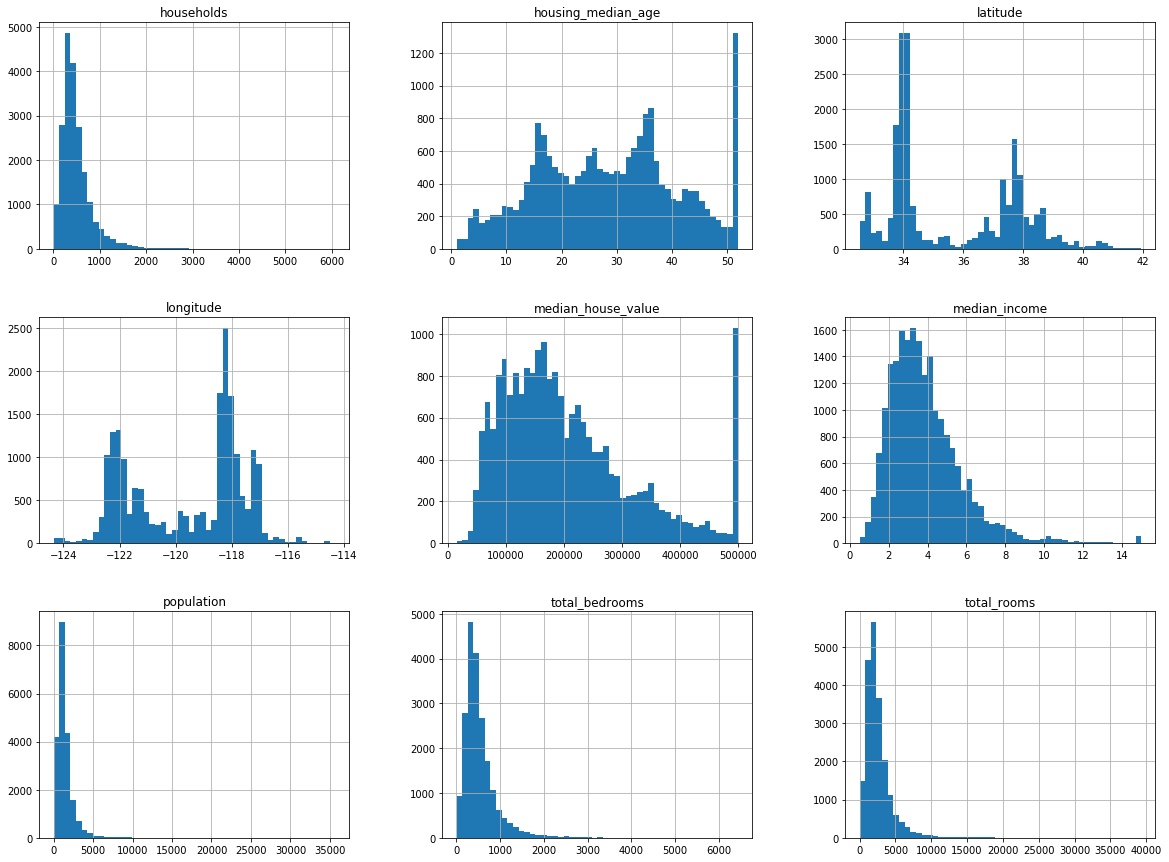

In [10]:
import matplotlib.pyplot as plt

housing.hist(bins=50, figsize=(20,15))
plt.show()

Plotting the histogram of each numerical attribute is a way of getting a visual summary of the dataset. You can individually plot the attributes but using the hist() method will plot all attributes at once.

Now that we have a summary of our dataset, we know split the dataset into two namely a training set and a testing set. The training set is the data we feed directly to the algorithm while the testing set is used for testing the accuracy. A different data is used for the testing since using the same data as the one in training may result in a faulty accuracy. Usually, the training set contains 80% of the data while the testing set contains only 20%. This is because the more data the algorithm has, the better the model is.

In [23]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

housing_add = "/Users/ritchevy/Desktop/Housing.csv"
housing = pd.read_csv(housing_add)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state = 42)

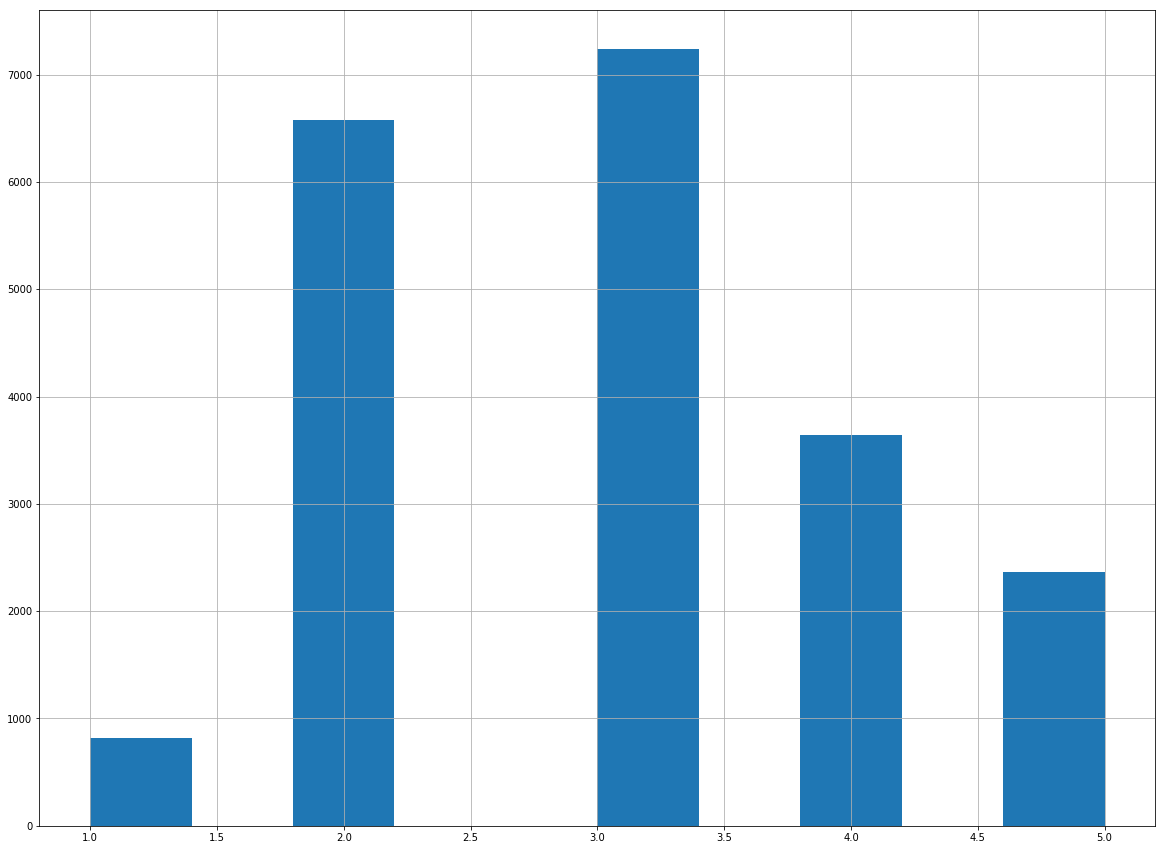

In [35]:
housing["income_cat"] = np.ceil(housing["median_income"]/1.5)
housing["income_cat"].where(housing["income_cat"] < 5, 5.0, inplace=True)
housing["income_cat"].hist(bins = 10, figsize =(20,15))


In this code, we reduced the number of strata to only 5. This is to prevent the algorithm from having a false estimate of a stratum's importance and percieve a bias. Also by looking at the graph, the data resembles more of a bell curve minus the outliers which is ideal.

In [29]:
from sklearn.model_selection import StratifiedShuffleSplit

#housing["income_cat"].value_counts()/len(housing)

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]
    
for set in (strat_train_set, strat_test_set):
    set.drop(["income_cat"], axis=1, inplace=True)



This code uses Stratified sampling then deletes the income_cat attribute from the data set. There are a variety opf advantages in using a stratified sampling over a randomized one. A random sampling amy give us a skewed data which is harder to process.

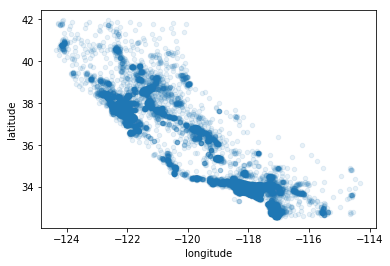

In [36]:
#housing = strat_train_test.copy()

housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

Here we graphed the longitude and latitude of the dataset. Now we can clearly see the graph looks alot like california now. But graphing the location alone won't give us any insight. Hence we include more attributes into the graph.

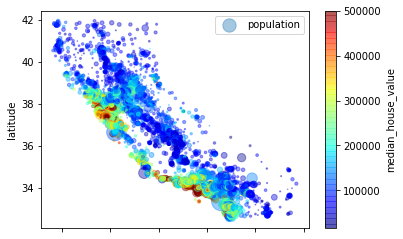

In [48]:
import matplotlib.pyplot as plt

housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
            s=housing["population"]/100, label="population", 
            c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
            )
plt.legend()